Size | Basic | NumPy
3x3 0.000017 0.000054
6x6 0.000056 0.000009
12x12 0.000340 0.000007
24x24 0.002247 0.000029
48x48 0.017720 0.000046
96x96 0.137650 0.000215
192x192 1.097513 0.000656
384x384 9.464968 0.003293


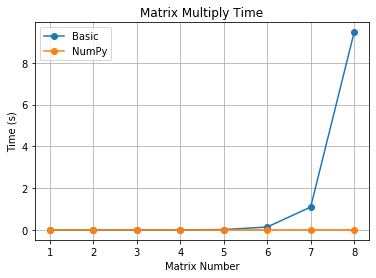

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time


def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j]+=A[i][k]*B[k][j]
    return C


sizes = [3]
for i in range(7):
    sizes.append(sizes[-1]*2)

times_basic = []
times_numpy = []
nums = list(range(1, 9))


for s in sizes:
    A = np.random.rand(s, s)
    B = np.random.rand(s, s)

    A_list = A.tolist()
    B_list = B.tolist()

    t1 = time.perf_counter()
    naive_matrix_multiplication(A_list, B_list)
    t2 = time.perf_counter()
    times_basic.append(t2 - t1)

    t1 = time.perf_counter()
    A @ B
    t2 = time.perf_counter()
    times_numpy.append(t2 - t1)


print("Size | Basic | NumPy")
for i in range(len(sizes)):
    print(f"{sizes[i]}x{sizes[i]} {times_basic[i]:.6f} {times_numpy[i]:.6f}")


plt.plot(nums, times_basic, marker='o', label='Basic')
plt.plot(nums, times_numpy, marker='o', label='NumPy')

plt.xlabel("Matrix Number")
plt.ylabel("Time (s)")
plt.title("Matrix Multiply Time")
plt.xticks(nums)
plt.legend()
plt.grid(True)

plt.show()